# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('data-imbalance-causal-forest'):
    os.chdir('..')

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import norm

# estimators
from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS

from scipy.integrate import quad 

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 

# DGP

There are $K$ groups of customers, each with $N_k$ observations. In this case the researchers observe individual characteristics $\vec{X}_{ki}\in \mathcal{X}\subset\mathbb{R}^D$. The heterogeneous treatment effect is a $\mathcal{X}$-measurable function $\tau: \mathcal{X} \mapsto \mathbb{R}$. The DGP is the following: 

$$
\begin{aligned}
Y_{ki} & = \tau(\vec{X}_{ki}) T_{ki} + \mathcal{N}(0, \sigma_Y^2) \\
T_{ki} & \sim B(p) \\ 
\vec{X}_{ki} & \sim \mathcal{N}(\vec{\mu}_k, \text{diag}(\vec{\sigma}_k^2)),\;\quad \forall\; k \\ 
\vec{\mu}_k & \sim U[-1, 1]^D,\;\quad \forall\; k \\ 
\vec{\sigma}_k & \sim U[0, 1]^D,\;\quad \forall\; k
\end{aligned}
$$

In [6]:
""" 
Data Generation Process
"""
def generate_customer_groups(num_cust: int, feat_dim: int) -> tuple:
    sigma_arr = np.random.uniform(0, 0.5, size=(num_cust, feat_dim))  # (num_cust, feat_dim): standard deviation of each feature for each customer
    mu_arr = np.random.uniform(-0.1, 0.1, size=(num_cust, feat_dim))  # (num_cust, feat_dim): mean of each feature for each customer

    return mu_arr, sigma_arr

def generate_individual(mu: np.ndarray, sigma: np.ndarray, num_obs: int, feat_dim: int) -> np.ndarray:
    # individual characteristics
    num_cust = mu.shape[0]
    X_arr = np.zeros(shape=(num_cust, num_obs, feat_dim))
    for cust_id in range(num_cust):
        X_arr[cust_id] = np.random.multivariate_normal(mu[cust_id], np.diag(sigma[cust_id]), size=num_obs)

    return X_arr

def generate_training_set(num_cust: int, num_obs: int, feat_dim: int, te_func: callable, meta_data: dict = None) -> tuple:
    """ 
    Sample data from the data generation process

    Return 
    ------
    (meta_data, data): meta_data contains the prior parameteres mu and sigma, data contains X, T, Y
    """

    # generate customer groups (prior parameters)
    if meta_data is None:
        mu_arr, sigma_arr = generate_customer_groups(num_cust, feat_dim)  # (num_cust, feat_dim), (num_cust, feat_dim)
    else:
        mu_arr, sigma_arr = meta_data['mu'], meta_data['sigma']

    # generate individual characteristics
    X_arr = generate_individual(mu_arr, sigma_arr, num_obs, feat_dim)  # (num_cust, num_obs, feat_dim)

    # generate treatment effect
    te_arr = te_func(X_arr)  # (num_cust, num_obs)

    # generate treatment variables
    treatment_arr = np.random.binomial(1, 0.5, size=(num_cust, num_obs))  # (num_cust, num_obs)

    # generate outcome variables
    outcome_arr = te_arr * treatment_arr + np.random.normal(0, 0.1, size=(num_cust, num_obs))  # (num_cust, num_obs)

    return {'mu': mu_arr, 'sigma': sigma_arr}, {'X': X_arr, 'T': treatment_arr, 'Y': outcome_arr}

In [7]:
"""  
Preprocessing
"""
def prepare_training_data(data: dict) -> dict:
    train_treatment_arr = data['T'].flatten().reshape(-1, 1)  # (num_cust, num_obs) -> (num_cust * num_obs, 1)
    train_outcome_arr = data['Y'].flatten().reshape(-1, 1)  # (num_cust, num_obs) -> (num_cust * num_obs, 1)
    train_X_arr = data['X'].reshape(-1, data['X'].shape[-1])  # (num_cust, num_obs, feat_dim) -> (num_cust * num_obs, feat_dim)

    return {
        'X': train_X_arr, 'T': train_treatment_arr, 'Y': train_outcome_arr
    }

In [8]:
"""  
Training and estimation
"""
def train_vanilla_causal_forest(X: np.ndarray, T: np.ndarray, Y: np.ndarray) -> CausalForest:
    cf = CausalForest(n_estimators=100)
    cf.fit(X=X, T=T, y=Y)

    return cf

def train_bootstrapped_causal_forest(
        X: np.ndarray, T: np.ndarray, Y: np.ndarray, num_bootstraps: int = 50, bootstrap_sample_size: int = 500
) -> list: 
    cf_list = [None for _ in range(num_bootstraps)]
    for i in range(num_bootstraps):
        # sample with replacement
        idx = np.random.choice(range(X.shape[0]), size=bootstrap_sample_size, replace=True)

        # fit causal forest to data set
        cf = CausalForest()
        cf.fit(X=X[idx], T=T[idx], y=Y[idx])

        cf_list[i] = cf

    return cf_list

def estimate_via_vanila_causal_forest(cf: CausalForest, X: np.ndarray) -> tuple:
    """ 

    Input 
    -----
    cf: trained CausalForest object
    X: (N, feat_dim)
    
    Return 
    ------
    (te_est, te_var): tuple of np.ndarray, treatment effect prediction (num_cust * num_obs, 1)
      and its variance (num_cust * num_obs, 1)
    """
    te_est, te_var = cf.predict_and_var(X)
    
    return te_est.flatten(), te_var.flatten()

def estimate_via_bootstrapped_causal_forest(cf_list: list, X: np.ndarray) -> pd.DataFrame:
    """ 
    
    Input 
    -----
    cf_list: list of trained CausalForest objects
    X: shape = (N, feat_dim)

    Return
    ------
    pd.DataFrame: (N, num_bootstraps), treatment effect prediction for each observation (row) and each bootstrap (column)
    """

    return pd.DataFrame({
        f'Booststrap {i}': cf.predict(X).flatten()
        for i, cf in enumerate(cf_list)
    })  # (N, num_bootstraps)

In [9]:
# training parameters
num_cust = 10  # number of customers (or customer clusters)
num_obs = 150 # number of observations for each group of customers
feat_dim = 10  # number of features for each indivdiual
te_func = lambda x_arr: x_arr[:, :, 0] ** 2 - 2 * x_arr[:, :, 1] # true treatment effect function

# testing parameters
num_test_obs = 1  # number of test observations for each group of customers

# generate raw data
meta_dict, data_dict = generate_training_set(num_cust, num_obs, feat_dim, te_func)
test_x_arr = generate_individual(**meta_dict, num_obs=num_test_obs, feat_dim=feat_dim)  # (num_cust, num_test_obs, feat_dim)

# data preparation
train_dict = prepare_training_data(data_dict)

vanilla_cf = train_vanilla_causal_forest(**train_dict)

In [10]:
pred_arr, var_arr = vanilla_cf.predict_and_var(test_x_arr.reshape(-1, feat_dim))
is_pred_arr = vanilla_cf.oob_predict(train_dict['X'])

In [11]:
# comparative statics: sample size on prediction variance

# training parameters
num_cust = 10  # number of customers (or customer clusters)
feat_dim = 10  # number of features for each indivdiual
te_func = lambda x_arr: x_arr[:, :, 0] ** 2 - 2 * x_arr[:, :, 1] # true treatment effect function

# experiment parameters
num_repeats = 20
sample_size_arr = np.arange(100, 1000, 100)
result_list = [None for _ in range(len(sample_size_arr))]

# generate prior (meta data)
mu_arr, sigma_arr = generate_customer_groups(num_cust, feat_dim)
meta_dict = {'mu': mu_arr, 'sigma': sigma_arr}

for i, sample_size in tqdm(enumerate(sample_size_arr)):
    repeated_result_list = [None for _ in range(num_repeats)]
    for j in range(num_repeats):
        # generate training data
        train_dict = prepare_training_data(generate_training_set(num_cust, sample_size, feat_dim, te_func, meta_dict)[1])
        test_x_arr = generate_individual(**meta_dict, num_obs=1, feat_dim=feat_dim)

        # train vanilla causal forest
        cf = train_vanilla_causal_forest(**train_dict)

        # predict treatment effect
        is_pred_arr = cf.oob_predict(train_dict['X'])  # in-sample prediction
        oos_pred_arr, oos_var_arr = cf.predict_and_var(test_x_arr.reshape(-1, feat_dim))  # out-of-sample prediction

        repeated_result_list[j] = {
            'is_pred': is_pred_arr, 'oos_pred': oos_pred_arr, 'oos_var': oos_var_arr
        }

    result_list[i] = repeated_result_list

9it [01:01,  6.85s/it]


In [12]:
compare_list = [None for _ in range(sample_size_arr.shape[0])]

for i in range(sample_size_arr.shape[0]):
    compare_list[i]= np.concatenate([
        result_list[i][repeat]['oos_var'].flatten()[np.newaxis, :] for repeat in range(num_repeats)
    ], axis=0).mean(axis=0)[np.newaxis, :]  # mean of (num_repeats, num_cust) over the first axis, get (1, num_cust)

compare_arr = np.concatenate(compare_list, axis=0)  # (num_sample_size, num_cust)

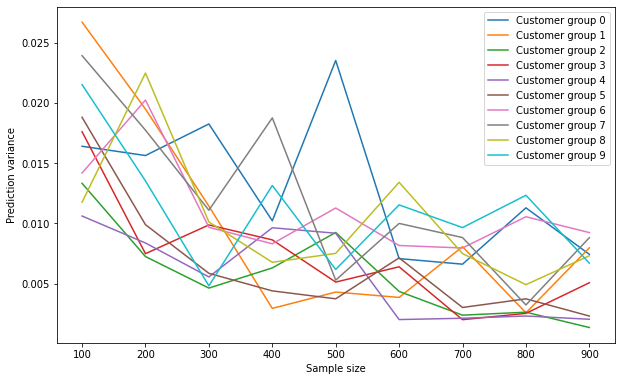

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

for i in range(num_cust):
    ax.plot(sample_size_arr, compare_arr[:, i], label=f'Customer group {i}')

ax.set_xlabel('Sample size')
ax.set_ylabel('Prediction variance')
ax.legend()

plt.legend()
plt.show()